In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
!unzip archive.zip

Archive:  archive.zip
  inflating: Asirra: cat vs dogs/cat.0.jpg  
  inflating: Asirra: cat vs dogs/cat.0.xml  
  inflating: Asirra: cat vs dogs/cat.1.jpg  
  inflating: Asirra: cat vs dogs/cat.1.xml  
  inflating: Asirra: cat vs dogs/cat.10.jpg  
  inflating: Asirra: cat vs dogs/cat.10.xml  
  inflating: Asirra: cat vs dogs/cat.11.jpg  
  inflating: Asirra: cat vs dogs/cat.11.xml  
  inflating: Asirra: cat vs dogs/cat.12.jpg  
  inflating: Asirra: cat vs dogs/cat.12.xml  
  inflating: Asirra: cat vs dogs/cat.13.jpg  
  inflating: Asirra: cat vs dogs/cat.13.xml  
  inflating: Asirra: cat vs dogs/cat.14.jpg  
  inflating: Asirra: cat vs dogs/cat.14.xml  
  inflating: Asirra: cat vs dogs/cat.15.jpg  
  inflating: Asirra: cat vs dogs/cat.15.xml  
  inflating: Asirra: cat vs dogs/cat.16.jpg  
  inflating: Asirra: cat vs dogs/cat.16.xml  
  inflating: Asirra: cat vs dogs/cat.17.jpg  
  inflating: Asirra: cat vs dogs/cat.17.xml  
  inflating: Asirra: cat vs dogs/cat.18.jpg  
  inflating: Asi

In [ ]:
import os
print(os.listdir())

['.config', 'archive.zip', 'Asirra: cat vs dogs', 'sample_data']


In [ ]:
print(os.listdir('Asirra: cat vs dogs'))

['cat.3884.jpg', 'dog.78.jpg', 'dog.3534.jpg', 'cat.3669.xml', 'dog.268.xml', 'cat.3652.jpg', 'dog.429.xml', 'dog.248.xml', 'dog.455.xml', 'dog.422.jpg', 'dog.3545.jpg', 'cat.3944.xml', 'dog.97.xml', 'dog.256.jpg', 'cat.3503.xml', 'cat.3730.xml', 'dog.242.jpg', 'cat.3830.jpg', 'cat.3536.jpg', 'dog.15.jpg', 'dog.157.xml', 'dog.248.jpg', 'dog.291.xml', 'dog.149.jpg', 'dog.473.jpg', 'dog.40.jpg', 'dog.409.jpg', 'dog.114.xml', 'dog.373.xml', 'cat.3604.xml', 'dog.3548.jpg', 'cat.5.xml', 'cat.3671.xml', 'cat.3793.jpg', 'cat.26.jpg', 'cat.3764.xml', 'dog.217.xml', 'cat.3539.xml', 'dog.231.xml', 'dog.423.jpg', 'dog.371.xml', 'cat.3844.xml', 'cat.3890.jpg', 'dog.395.xml', 'cat.3597.xml', 'dog.340.jpg', 'dog.221.jpg', 'cat.3914.xml', 'dog.2.jpg', 'dog.61.jpg', 'cat.3809.jpg', 'cat.22.xml', 'dog.192.jpg', 'cat.3754.xml', 'cat.3915.jpg', 'dog.195.jpg', 'cat.3720.xml', 'cat.3694.xml', 'dog.324.jpg', 'cat.21.jpg', 'cat.3577.jpg', 'dog.50.xml', 'cat.3955.xml', 'dog.12.xml', 'dog.477.xml', 'cat.3616.j

In [ ]:
import os

os.makedirs('data/Cat', exist_ok=True)
os.makedirs('data/Dog', exist_ok=True)

In [ ]:
import shutil

source_folder = "Asirra: cat vs dogs"

for file in os.listdir(source_folder):
    if file.endswith(".jpg"):
        if file.startswith("cat"):
            shutil.move(os.path.join(source_folder, file), "data/Cat")
        elif file.startswith("dog"):
            shutil.move(os.path.join(source_folder, file), "data/Dog")

In [ ]:
dataset = tf.keras.utils.image_dataset_from_directory(
    "data",
    image_size=(160,160),
    batch_size=32
)

Found 1100 files belonging to 2 classes.


In [ ]:
train_size = int(0.8 * len(dataset))

train_ds = dataset.take(train_size)
val_ds = dataset.skip(train_size)

In [ ]:
import tensorflow as tf

normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(160,160,3)),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.5368 - loss: 0.7743 - val_accuracy: 0.5686 - val_loss: 0.6800
Epoch 2/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.5212 - loss: 0.6851 - val_accuracy: 0.5539 - val_loss: 0.6675
Epoch 3/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.6484 - loss: 0.6425 - val_accuracy: 0.7059 - val_loss: 0.5644
Epoch 4/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.6350 - loss: 0.6455 - val_accuracy: 0.6471 - val_loss: 0.6088
Epoch 5/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.6819 - loss: 0.5924 - val_accuracy: 0.7010 - val_loss: 0.5559


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

img = image.load_img('data/Cat/cat.1.jpg', target_size=(160,160))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction > 0.5:
    print("Dog 🐶")
else:
    print("Cat 🐱")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
Cat 🐱


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive (1).zip


In [ ]:
import zipfile

with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall('dataset')

In [ ]:
import os, shutil

os.makedirs('data/Cat', exist_ok=True)
os.makedirs('data/Dog', exist_ok=True)

source_folder = "dataset/Asirra: cat vs dogs"

for file in os.listdir(source_folder):
    if file.endswith(".jpg"):
        src = os.path.join(source_folder, file)

        if file.startswith("cat"):
            dst = os.path.join("data/Cat", file)

        elif file.startswith("dog"):
            dst = os.path.join("data/Dog", file)

        # 🔥 IMPORTANT: Only move if file does NOT already exist
        if not os.path.exists(dst):
            shutil.move(src, dst)

In [ ]:
import tensorflow as tf

dataset = tf.keras.utils.image_dataset_from_directory(
    "data",
    image_size=(160,160),
    batch_size=32
)

Found 1100 files belonging to 2 classes.


In [ ]:
import tensorflow as tf

dataset = tf.keras.utils.image_dataset_from_directory(
    "data",
    image_size=(160,160),
    batch_size=32
)

Found 1100 files belonging to 2 classes.


In [ ]:
train_size = int(0.8 * len(dataset))

train_ds = dataset.take(train_size)
val_ds = dataset.skip(train_size)

In [ ]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(160,160,3)),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.5279 - loss: 0.7326 - val_accuracy: 0.4902 - val_loss: 0.6902
Epoch 2/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.5536 - loss: 0.6859 - val_accuracy: 0.5441 - val_loss: 0.6624
Epoch 3/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.6105 - loss: 0.6563 - val_accuracy: 0.6324 - val_loss: 0.6396
Epoch 4/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.6395 - loss: 0.6338 - val_accuracy: 0.7353 - val_loss: 0.5761
Epoch 5/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.7288 - loss: 0.5475 - val_accuracy: 0.7402 - val_loss: 0.5158


In [ ]:
print("Training Accuracy   :", max(history.history['accuracy']))
print("Validation Accuracy :", max(history.history['val_accuracy']))
print("Loss                :", min(history.history['loss']))

Training Accuracy   : 0.7287946343421936
Validation Accuracy : 0.7401960492134094
Loss                : 0.5475029349327087


In [ ]:
uploaded = files.upload()

Saving dog.jpg to dog.jpg


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

img = image.load_img(list(uploaded.keys())[0], target_size=(160,160))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)[0][0]

if prediction > 0.5:
    print("Predicted Class : Dog 🐶")
    print("Confidence      :", round(prediction * 100, 2), "%")
else:
    print("Predicted Class : Cat 🐱")
    print("Confidence      :", round((1 - prediction) * 100, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
Predicted Class : Dog 🐶
Confidence      : 57.82 %


In [ ]:
print("\n----------------------------------------")
print("     PET FACE CLASSIFICATION SYSTEM")
print("----------------------------------------")
print("\nUploaded Image :", list(uploaded.keys())[0])
print("\nPrediction:")

if prediction > 0.5:
    print("Class      : Dog 🐶")
    print("Confidence :", round(prediction * 100, 2), "%")
else:
    print("Class      : Cat 🐱")
    print("Confidence :", round((1 - prediction) * 100, 2), "%")

print("\nStatus     : Successfully Classified")
print("----------------------------------------")


----------------------------------------
     PET FACE CLASSIFICATION SYSTEM
----------------------------------------

Uploaded Image : dog.jpg

Prediction:
Class      : Dog 🐶
Confidence : 57.82 %

Status     : Successfully Classified
----------------------------------------


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving dog.jpg to dog (1).jpg


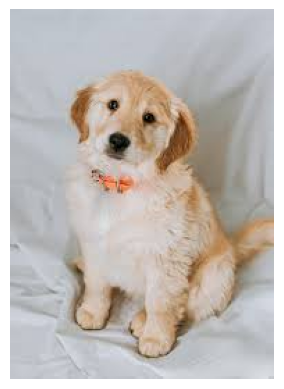

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img_path = list(uploaded.keys())[0]
img = Image.open(img_path)

plt.imshow(img)
plt.axis('off')
plt.show()